## 1. Imports and study configuration

In [10]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import coffea.util
from IPython.display import display


def find_sidm_dir(start):
    for candidate in (start, *start.parents):
        if (candidate / "tools").is_dir() and (candidate / "configs").is_dir():
            return candidate
    raise RuntimeError("Could not locate the sidm package directory")


SIDM_DIR = find_sidm_dir(Path.cwd().resolve())
REPO_DIR = SIDM_DIR.parent
NOTEBOOK_DIR = SIDM_DIR / "studies" / "Muon_selection"
if str(REPO_DIR) not in sys.path:
    sys.path.insert(1, str(REPO_DIR))

from sidm.tools import utilities

utilities.set_plot_style()
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

COFFEA_DIR = NOTEBOOK_DIR / "coffea_outputs_muon_selection_integrated"
FIGURE_DIR = NOTEBOOK_DIR / "figures_muon_selection_summary"
TABLE_DIR = NOTEBOOK_DIR / "tables_muon_selection_summary"
SAVE_FIGURES = False
SAVE_CSV = False
PLOT_LINEWIDTH = 2.5

COFFEA_FILES = [
    COFFEA_DIR / "signal_2mu2e_integrated_full.coffea",
    COFFEA_DIR / "signal_4mu_integrated_full.coffea",
]
SAMPLE_ORDER = [
    "2Mu2E_500GeV_0p25GeV_2p0mm",
    "4Mu_500GeV_0p25GeV_2p0mm",
]

CHANNELS = {
    "baseline": "baseNoLj_No_Muon_Constraint",
    "even_charge": "baseNoLj_Even_Muon_Charge",
    "nmu_eq1": "baseNoLj_Only_One_Muon",
    "nmu_eq2": "baseNoLj_Only_Two_Muon",
    "nmu_eq3": "baseNoLj_Only_Three_Muon",
    "nmu_ge4": "baseNoLj_Four_Ormore_Muon",
    "nmu_ge2": "baseNoLj_Two_Ormore_Muon",
    "nmu_ge2_displacement": "baseNoLj_Two_Ormore_Muon_Displacement",
    "nmu_ge2_displacement_iso": (
        "baseNoLj_Two_Ormore_Muon_Displacement_EgmIso_MuIso"
    ),
}
CHANNEL_LABELS = {
    CHANNELS["baseline"]: "Baseline",
    CHANNELS["even_charge"]: "Even charge",
    CHANNELS["nmu_eq1"]: r"$N_{\mu}=1$",
    CHANNELS["nmu_eq2"]: r"$N_{\mu}=2$",
    CHANNELS["nmu_eq3"]: r"$N_{\mu}=3$",
    CHANNELS["nmu_ge4"]: r"$N_{\mu}\geq4$",
    CHANNELS["nmu_ge2"]: r"$N_{\mu}\geq2$",
    CHANNELS["nmu_ge2_displacement"]: r"$N_{\mu}\geq2$ + displacement",
    CHANNELS["nmu_ge2_displacement_iso"]: (
        r"$N_{\mu}\geq2$ + displacement + isolation"
    ),
}

CHANNEL_COLORS = {
    CHANNELS["baseline"]: "black",
    CHANNELS["even_charge"]: "tab:blue",
    CHANNELS["nmu_eq2"]: "tab:green",
    CHANNELS["nmu_ge2"]: "tab:red",
    CHANNELS["nmu_ge2_displacement"]: "tab:orange",
    CHANNELS["nmu_ge2_displacement_iso"]: "tab:purple",
}

DIRECT_CHANNELS = [
    CHANNELS["baseline"],
    CHANNELS["even_charge"],
    CHANNELS["nmu_eq2"],
    CHANNELS["nmu_ge2"],
]
MULTIPLICITY_CHANNELS = [
    CHANNELS["nmu_eq1"],
    CHANNELS["nmu_eq2"],
    CHANNELS["nmu_eq3"],
    CHANNELS["nmu_ge4"],
]
DIRECT_HISTOGRAMS = {
    "mu_lj_pt": r"Muon-LJ $p_{\mathrm{T}}$",
    "genA_muLj_ptRatio": (
        r"Muon-LJ $p_{\mathrm{T}}/p_{\mathrm{T}}(Z_d^{\mathrm{gen}})$"
    ),
}
FINAL_VALIDATION_HISTOGRAMS = {
    "2Mu2E": "mulj_egmlj_invmass",
    "4Mu": "lj_lj_invmass",
}
LATER_CHANNELS = [
    CHANNELS["nmu_ge2"],
    CHANNELS["nmu_ge2_displacement"],
    CHANNELS["nmu_ge2_displacement_iso"],
]

In [2]:
out = {}
loaded_files = []

for coffea_file in COFFEA_FILES:
    if not coffea_file.exists():
        warnings.warn(f"Missing coffea file: {coffea_file}", RuntimeWarning)
        continue
    payload = coffea.util.load(coffea_file)
    if "out" not in payload:
        warnings.warn(
            f"Skipping {coffea_file}: top-level key 'out' is unavailable",
            RuntimeWarning,
        )
        continue
    loaded_files.append(coffea_file)
    for sample, sample_output in payload["out"].items():
        if sample in out:
            warnings.warn(
                f"Sample {sample} appears more than once; using {coffea_file}",
                RuntimeWarning,
            )
        out[sample] = sample_output

print("Loaded coffea files:")
for path in loaded_files:
    print(f"  - {path}")
print("\nAvailable samples:")
for sample in sorted(out):
    print(f"  - {sample}")

Loaded coffea files:
  - /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Muon_selection/coffea_outputs_muon_selection_integrated/signal_2mu2e_integrated_full.coffea
  - /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Muon_selection/coffea_outputs_muon_selection_integrated/signal_4mu_integrated_full.coffea

Available samples:
  - 2Mu2E_500GeV_0p25GeV_2p0mm
  - 4Mu_500GeV_0p25GeV_2p0mm


In [3]:
RELEVANT_CHANNELS = list(dict.fromkeys(
    DIRECT_CHANNELS + MULTIPLICITY_CHANNELS + LATER_CHANNELS
))

RELEVANT_HISTOGRAMS = list(dict.fromkeys(
    list(DIRECT_HISTOGRAMS)
    + list(FINAL_VALIDATION_HISTOGRAMS.values())
    + [
        "mu_lj_muon_min_dxy",
        "mu_lj_iso",
        "egm_lj_iso",
    ]
))


def histogram_channels(histogram):
    try:
        return set(histogram.axes["channel"])
    except (KeyError, TypeError):
        return set()


def available_relevant_channels(sample):
    available = set(out[sample].get("cutflow", {}))
    for histogram in out[sample].get("hists", {}).values():
        available.update(histogram_channels(histogram))
    return [channel for channel in RELEVANT_CHANNELS if channel in available]


for sample in [name for name in SAMPLE_ORDER if name in out]:
    available_hists = set(out[sample].get("hists", {}))
    channels = available_relevant_channels(sample)
    histograms = [
        name for name in RELEVANT_HISTOGRAMS if name in available_hists
    ]
    print(f"\n{sample}")
    print("  Relevant channels:")
    for channel in channels:
        print(f"    - {channel}")
    print("  Histograms used below:")
    for hist_name in histograms:
        print(f"    - {hist_name}")

    missing_channels = [
        channel for channel in RELEVANT_CHANNELS if channel not in channels
    ]
    missing_histograms = [
        name for name in RELEVANT_HISTOGRAMS if name not in available_hists
    ]
    if missing_channels:
        warnings.warn(
            f"{sample}: missing relevant channels {missing_channels}",
            RuntimeWarning,
        )
    if missing_histograms:
        warnings.warn(
            f"{sample}: missing histograms {missing_histograms}",
            RuntimeWarning,
        )


2Mu2E_500GeV_0p25GeV_2p0mm
  Relevant channels:
    - baseNoLj_No_Muon_Constraint
    - baseNoLj_Even_Muon_Charge
    - baseNoLj_Only_Two_Muon
    - baseNoLj_Two_Ormore_Muon
    - baseNoLj_Only_One_Muon
    - baseNoLj_Only_Three_Muon
    - baseNoLj_Four_Ormore_Muon
    - baseNoLj_Two_Ormore_Muon_Displacement
    - baseNoLj_Two_Ormore_Muon_Displacement_EgmIso_MuIso
  Histograms used below:
    - mu_lj_pt
    - genA_muLj_ptRatio
    - mulj_egmlj_invmass
    - mu_lj_muon_min_dxy
    - mu_lj_iso
    - egm_lj_iso

4Mu_500GeV_0p25GeV_2p0mm
  Relevant channels:
    - baseNoLj_No_Muon_Constraint
    - baseNoLj_Even_Muon_Charge
    - baseNoLj_Only_Two_Muon
    - baseNoLj_Two_Ormore_Muon
    - baseNoLj_Only_One_Muon
    - baseNoLj_Only_Three_Muon
    - baseNoLj_Four_Ormore_Muon
    - baseNoLj_Two_Ormore_Muon_Displacement
    - baseNoLj_Two_Ormore_Muon_Displacement_EgmIso_MuIso
  Histograms used below:
    - mu_lj_pt
    - genA_muLj_ptRatio
    - mulj_egmlj_invmass
    - mu_lj_muon_min_dxy
    -

/tmp/ipykernel_947/2108933375.py:56: RuntimeWarning: 2Mu2E_500GeV_0p25GeV_2p0mm: missing histograms ['mulj_mulj_invmass']
  warnings.warn(
/tmp/ipykernel_947/2108933375.py:56: RuntimeWarning: 4Mu_500GeV_0p25GeV_2p0mm: missing histograms ['mulj_mulj_invmass']
  warnings.warn(


## 3. Plotting and yield helpers

In [4]:
def available_samples():
    return [sample for sample in SAMPLE_ORDER if sample in out]


def inputs_available(sample, hist_name, channels):
    if sample not in out:
        warnings.warn(f"Skip plot: sample {sample} is unavailable", RuntimeWarning)
        return False
    if hist_name not in out[sample].get("hists", {}):
        warnings.warn(
            f"Skip {sample}/{hist_name}: histogram is unavailable",
            RuntimeWarning,
        )
        return False
    available = histogram_channels(out[sample]["hists"][hist_name])
    missing = [channel for channel in channels if channel not in available]
    if missing:
        warnings.warn(
            f"Skip {sample}/{hist_name}: missing channels {missing}",
            RuntimeWarning,
        )
        return False
    return True


def get_hist(sample, hist_name, channel):
    return out[sample]["hists"][hist_name][channel, :]


def hist_integral(histogram, flow=True):
    return float(histogram.sum(flow=flow).value)


def weighted_lj_yield(sample, channel):
    if not inputs_available(sample, "mu_lj_pt", [channel]):
        return np.nan
    return hist_integral(get_hist(sample, "mu_lj_pt", channel), flow=True)


def safe_divide(numerator, denominator):
    if denominator == 0 or not np.isfinite(denominator):
        return np.nan
    return numerator / denominator


def normalize_visible(histogram):
    total = hist_integral(histogram, flow=False)
    if total == 0:
        return None
    return histogram / total


def maybe_save(fig, filename):
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        path = FIGURE_DIR / filename
        fig.savefig(path, bbox_inches="tight")
        print(f"Saved {path}")


def show_and_close(fig, filename):
    if fig is None:
        return
    maybe_save(fig, filename)
    plt.show()
    plt.close(fig)


def plot_overlay(
    sample,
    hist_name,
    channels,
    normalized=False,
    ratio_denominator=None,
):
    if not inputs_available(sample, hist_name, channels):
        return None
    if ratio_denominator is not None and ratio_denominator not in channels:
        warnings.warn(
            f"Skip {sample}/{hist_name}: ratio denominator "
            f"{ratio_denominator} is not plotted",
            RuntimeWarning,
        )
        return None

    if ratio_denominator is None:
        fig, ax = plt.subplots(figsize=(20, 15))
        rax = None
    else:
        fig, (ax, rax) = plt.subplots(
            2,
            1,
            figsize=(20, 15),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1], "hspace": 0.0},
        )

    plotted = 0
    plotted_histograms = {}
    plotted_colors = {}
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    for index, channel in enumerate(channels):
        histogram = utilities.auto_rebin_hist(
            get_hist(sample, hist_name, channel),
            target_bins=25,
            rebin_threshold=25,
        )
        if normalized:
            histogram = normalize_visible(histogram)
            if histogram is None:
                warnings.warn(
                    f"Skip zero-integral curve: {sample}, {hist_name}, {channel}",
                    RuntimeWarning,
                )
                continue
        color = CHANNEL_COLORS.get(
        channel,
        colors[index % len(colors)],
        )
        hep.histplot(
            histogram,
            ax=ax,
            flow="none",
            histtype="step",
            linewidth=PLOT_LINEWIDTH,
            color=color,
            label=CHANNEL_LABELS.get(channel, channel),
        )
        plotted_histograms[channel] = histogram
        plotted_colors[channel] = color
        plotted += 1
    if plotted == 0:
        plt.close(fig)
        warnings.warn(
            f"Skip {sample}/{hist_name}: all requested curves are empty",
            RuntimeWarning,
        )
        return None
    ax.set_ylabel("Normalized entries" if normalized else "Weighted muon-LJ yield")
    ax.set_title(sample)
    ax.legend()
    hep.cms.label(ax=ax)
    if rax is not None and ratio_denominator in plotted_histograms:
        denominator = plotted_histograms[ratio_denominator]
        for channel in channels:
            if channel == ratio_denominator or channel not in plotted_histograms:
                continue
            numerator = plotted_histograms[channel]
            if normalized:
                denominator_values = denominator.values(flow=False)
                numerator_values = numerator.values(flow=False)
                ratio = np.divide(
                    numerator_values,
                    denominator_values,
                    out=np.full_like(numerator_values, np.nan, dtype=float),
                    where=denominator_values != 0,
                )
                rax.errorbar(
                    denominator.axes[0].centers,
                    ratio,
                    fmt="o",
                    color=plotted_colors[channel],
                )
            else:
                with np.errstate(divide="ignore", invalid="ignore"):
                    efficiency, errors = utilities.get_eff_hist(
                        numerator,
                        denominator,
                    )
                hep.histplot(
                    efficiency,
                    ax=rax,
                    histtype="errorbar",
                    yerr=errors,
                    color=plotted_colors[channel],
                )
        rax.axhline(1.0, color="gray", linestyle="--")
        if normalized:
            rax.set_ylabel("Shape / reference")
        else:
            rax.set_ylabel("Efficiency")
            rax.set_ylim(0, 1.2)
    else:
        fig.tight_layout()
    return fig

## 4. Direct selection comparison

Only baseline, even charge, exactly two muons, and at least two muons are compared. The muon-LJ
transverse-momentum plot retains weighted normalization so acceptance differences remain visible.
Both distributions retain their weighted normalization. Following the original notebook style,
the lower panels show the bin-by-bin selection efficiency relative to the baseline with error
bars. Unit-normalized shape comparisons are kept in the dedicated shape-preservation section.
LJ-LJ mass is reserved for the final validation section.

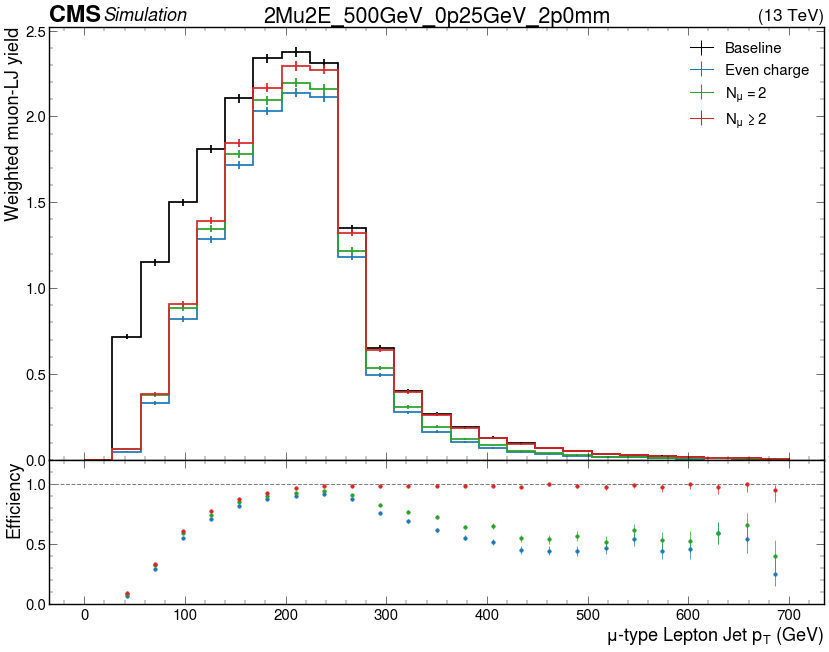

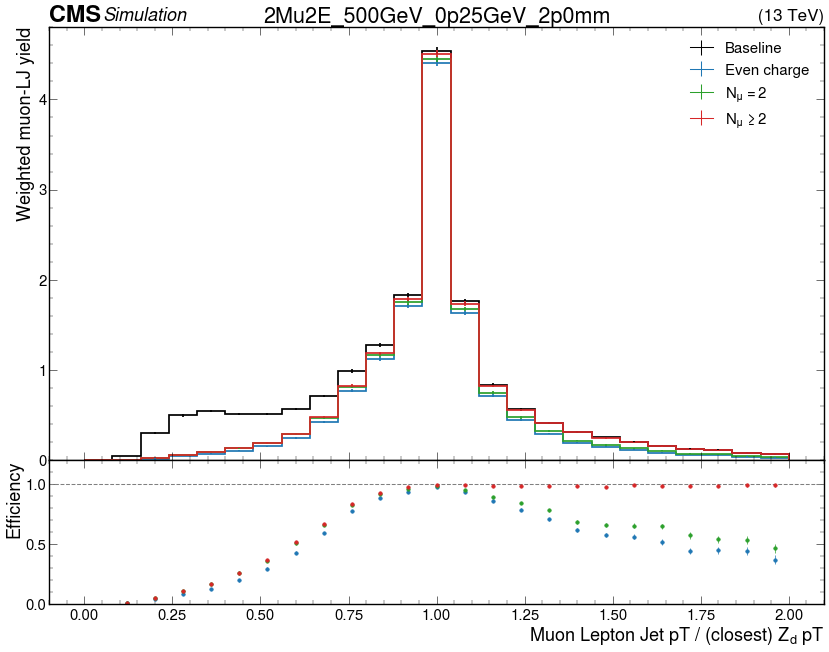

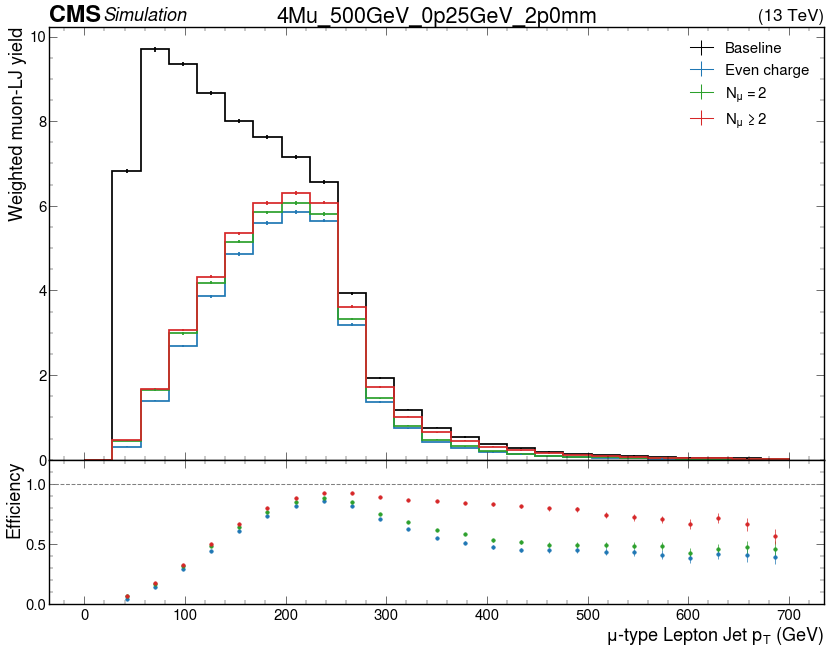

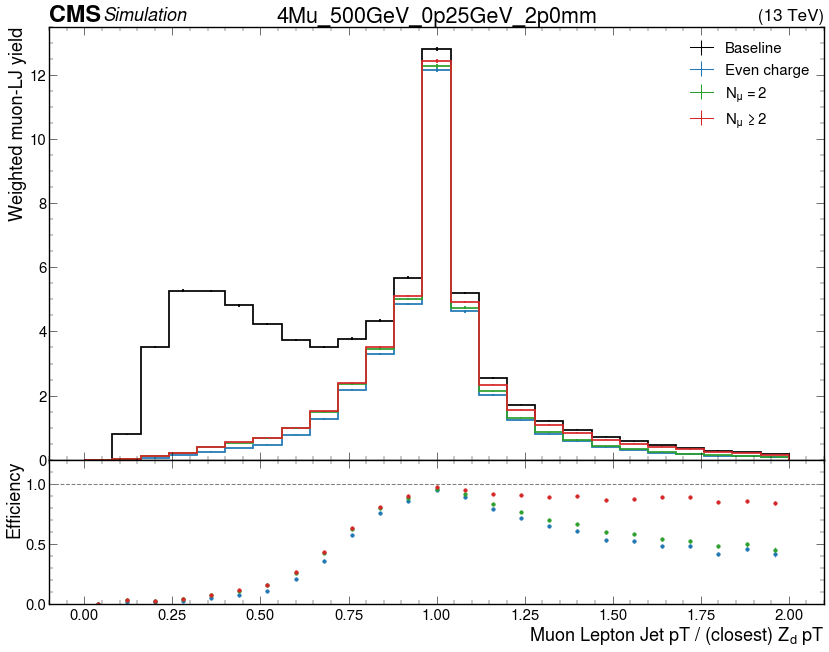

In [5]:
direct_plot_specs = [
    ("mu_lj_pt", False),
    ("genA_muLj_ptRatio", False),
]

for sample in available_samples():
    for hist_name, normalized in direct_plot_specs:
        fig = plot_overlay(
            sample,
            hist_name,
            DIRECT_CHANNELS,
            normalized=normalized,
            ratio_denominator=CHANNELS["baseline"],
        )
        suffix = "shape" if normalized else "weighted_yield"
        show_and_close(fig, f"direct_{hist_name}_{suffix}_{sample}.pdf")

## 5. Muon multiplicity composition

The denominator is the weighted number of muon-type LJs in the existing baseline channel,
obtained from the integral of the muon-LJ transverse-momentum histogram. The numerator channels
are mutually exclusive: \(N_\mu=1\), \(N_\mu=2\), \(N_\mu=3\), and \(N_\mu\geq4\).

2Mu2E_500GeV_0p25GeV_2p0mm: denominator = baseline weighted muon-LJ yield = 17.6585


,Muon multiplicity,Weighted muon-LJ yield,Fraction of baseline muon-LJs
0,$N_{\mu}=1$,3.0458,17.248%
1,$N_{\mu}=2$,13.5688,76.840%
2,$N_{\mu}=3$,1.01409,5.743%
3,$N_{\mu}\geq4$,0.0297604,0.169%


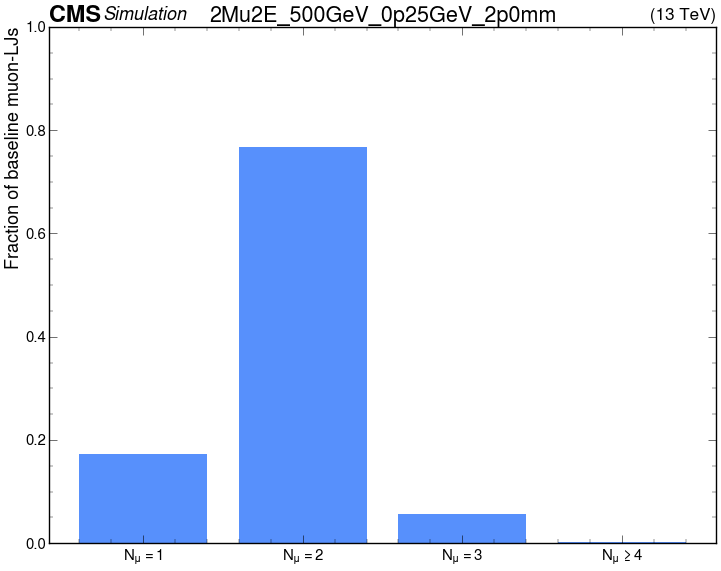

4Mu_500GeV_0p25GeV_2p0mm: denominator = baseline weighted muon-LJ yield = 73.7596


,Muon multiplicity,Weighted muon-LJ yield,Fraction of baseline muon-LJs
0,$N_{\mu}=1$,31.8179,43.137%
1,$N_{\mu}=2$,39.238,53.197%
2,$N_{\mu}=3$,2.6329,3.570%
3,$N_{\mu}\geq4$,0.0708416,0.096%


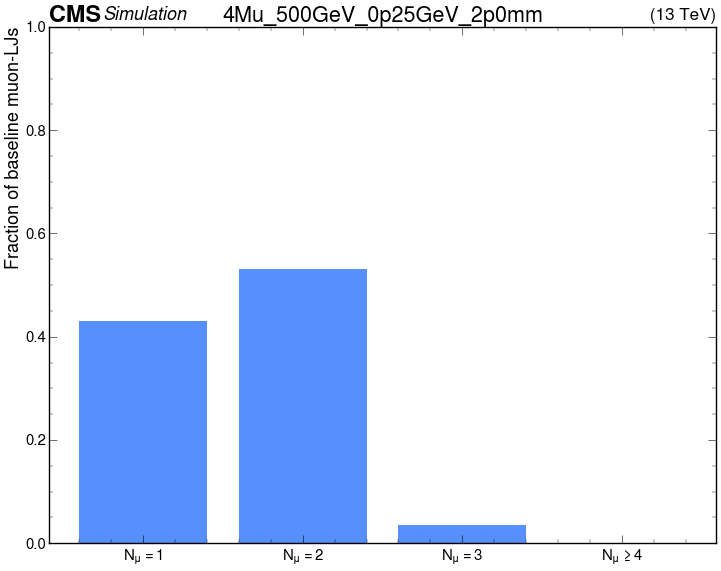

In [6]:
multiplicity_tables = {}
for sample in available_samples():
    baseline = weighted_lj_yield(sample, CHANNELS["baseline"])
    rows = []
    for channel in MULTIPLICITY_CHANNELS:
        value = weighted_lj_yield(sample, channel)
        rows.append({
            "Muon multiplicity": CHANNEL_LABELS[channel],
            "Weighted muon-LJ yield": value,
            "Fraction of baseline muon-LJs": safe_divide(value, baseline),
        })
    table = pd.DataFrame(rows)
    multiplicity_tables[sample] = table
    print(
        f"{sample}: denominator = baseline weighted muon-LJ yield = "
        f"{baseline:.6g}"
    )
    display(table.style.format({
        "Weighted muon-LJ yield": "{:.6g}",
        "Fraction of baseline muon-LJs": "{:.3%}",
    }))

    fig, ax = plt.subplots(figsize=(15, 12))
    ax.bar(
        table["Muon multiplicity"],
        table["Fraction of baseline muon-LJs"],
    )
    ax.set_ylabel("Fraction of baseline muon-LJs")
    ax.set_title(sample)
    ax.set_ylim(0, 1)
    hep.cms.label(ax=ax)
    fig.tight_layout()
    show_and_close(fig, f"multiplicity_composition_{sample}.pdf")

## 6. Efficiency and yield tables

Weighted yield means the weighted muon-LJ count from the full muon-LJ transverse-momentum
histogram, including flow bins. This object-level definition directly reflects the multiplicity
channels. Efficiency is the selected yield divided by baseline; relative change uses exactly two
muons as its denominator.

In [7]:
TABLE_CHANNELS = [
    CHANNELS["baseline"],
    CHANNELS["even_charge"],
    CHANNELS["nmu_eq2"],
    CHANNELS["nmu_ge2"],
]


def selection_table(sample):
    yields = {
        channel: weighted_lj_yield(sample, channel)
        for channel in TABLE_CHANNELS
    }
    baseline = yields[CHANNELS["baseline"]]
    exactly_two = yields[CHANNELS["nmu_eq2"]]
    rows = []
    for channel in TABLE_CHANNELS:
        value = yields[channel]
        rows.append({
            "Selection": CHANNEL_LABELS[channel],
            "Weighted yield": value,
            "Efficiency relative to baseline": safe_divide(value, baseline),
            "Relative change compared with exactly two muons": (
                safe_divide(value - exactly_two, exactly_two)
            ),
        })
    return pd.DataFrame(rows)


selection_tables = {}
for sample in available_samples():
    table = selection_table(sample)
    selection_tables[sample] = table
    print(sample)
    display(table.style.format({
        "Weighted yield": "{:.6g}",
        "Efficiency relative to baseline": "{:.3%}",
        "Relative change compared with exactly two muons": "{:+.3%}",
    }))
    if SAVE_CSV:
        TABLE_DIR.mkdir(parents=True, exist_ok=True)
        csv_path = TABLE_DIR / f"muon_selection_{sample}.csv"
        table.to_csv(csv_path, index=False)
        print(f"Saved {csv_path}")

2Mu2E_500GeV_0p25GeV_2p0mm


,Selection,Weighted yield,Efficiency relative to baseline,Relative change compared with exactly two muons
0,Baseline,17.6585,100.000%,+30.140%
1,Even charge,12.9416,73.288%,-4.622%
2,$N_{\mu}=2$,13.5688,76.840%,+0.000%
3,$N_{\mu}\geq2$,14.6127,82.752%,+7.693%


4Mu_500GeV_0p25GeV_2p0mm


,Selection,Weighted yield,Efficiency relative to baseline,Relative change compared with exactly two muons
0,Baseline,73.7596,100.000%,+87.980%
1,Even charge,36.8606,49.974%,-6.059%
2,$N_{\mu}=2$,39.238,53.197%,+0.000%
3,$N_{\mu}\geq2$,41.9418,56.863%,+6.891%


## 8. Subsequent LJ-level selections

Displacement and isolation are not part of the finalized multiplicity definition. They are shown
only through existing channels that already include \(N_\mu\geq2\): at least two muons; at
least two plus displacement; and at least two plus displacement and both isolation selections.
Each lower panel uses the existing \(N_\mu\geq2\) channel as its reference.

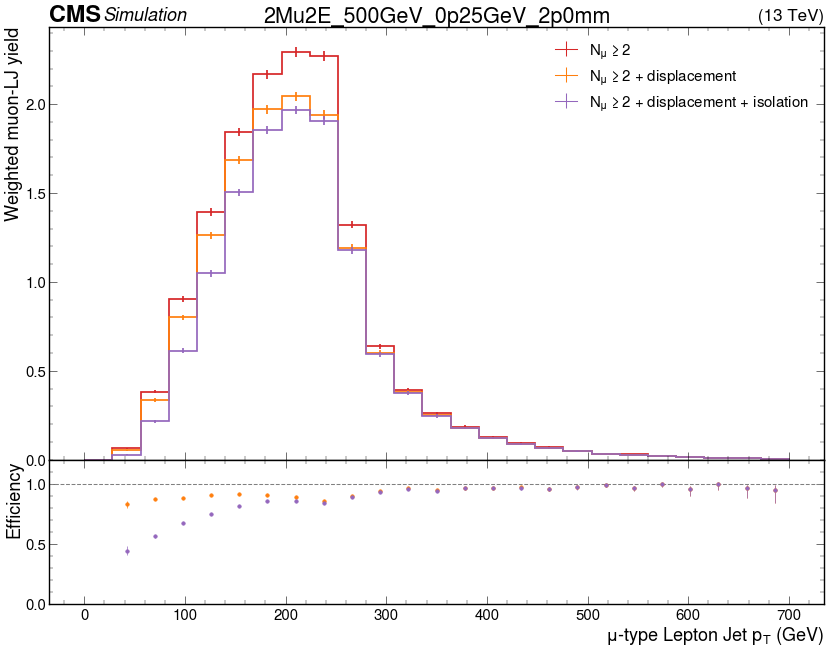

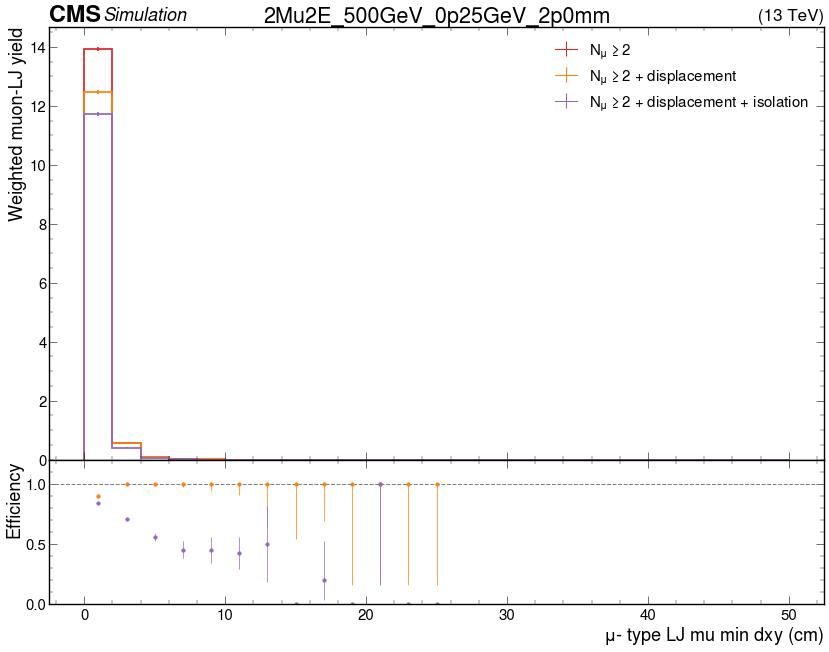

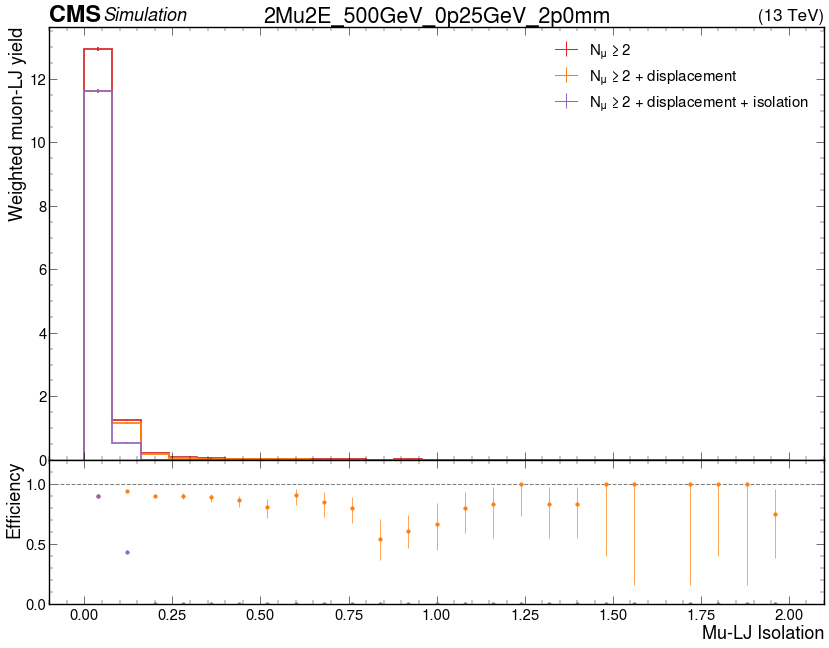

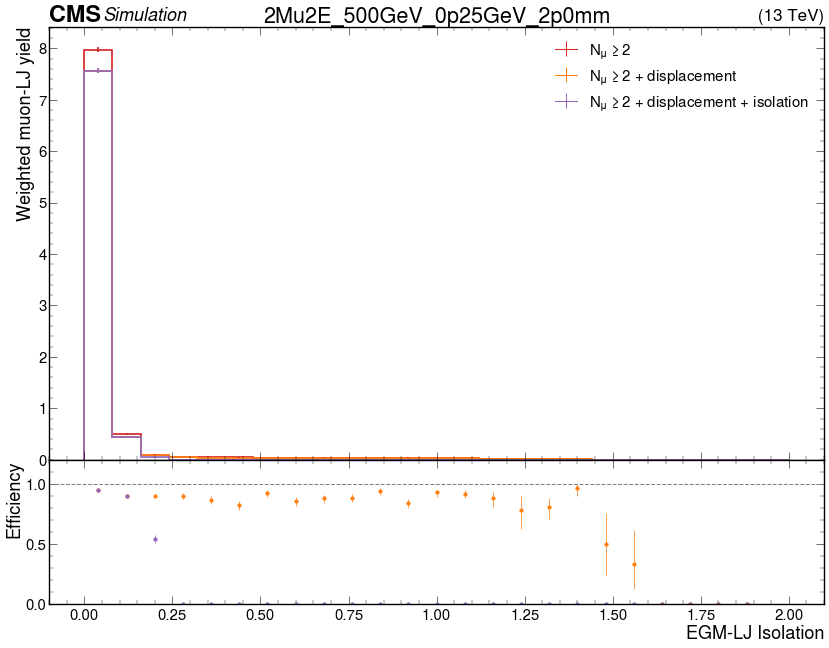

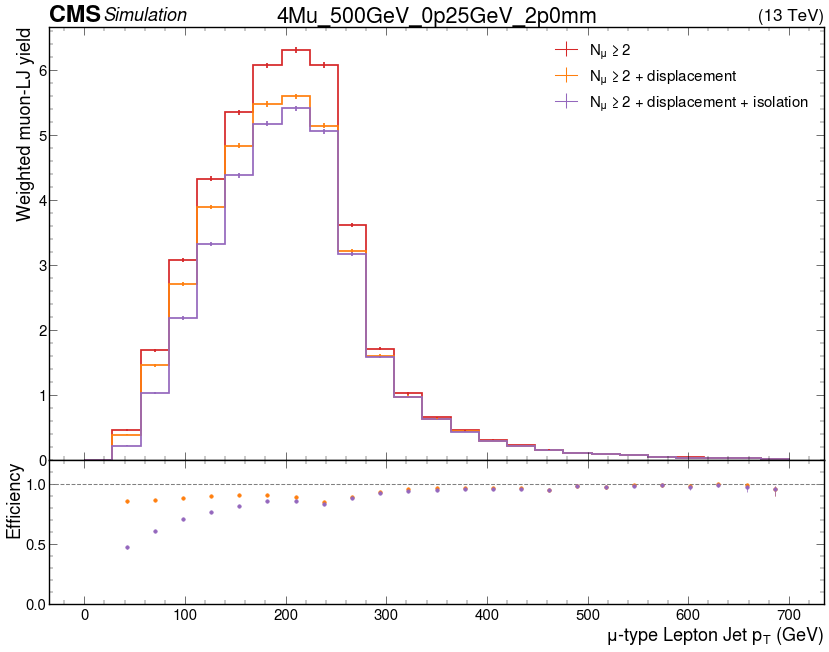

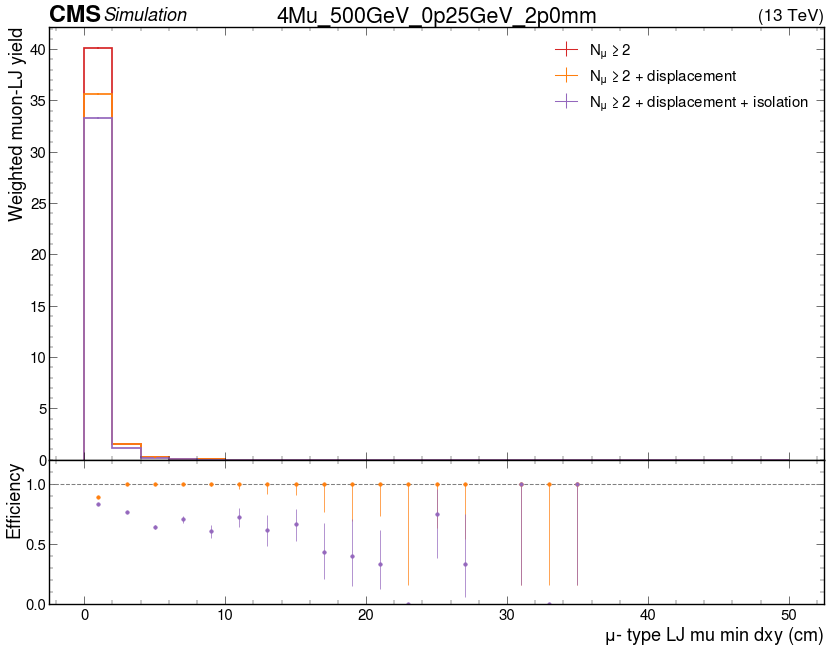

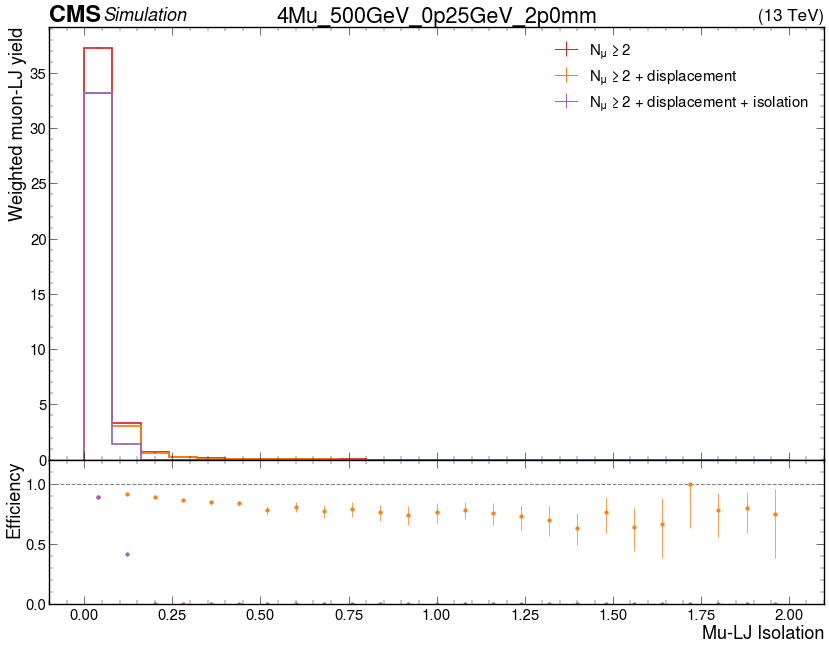

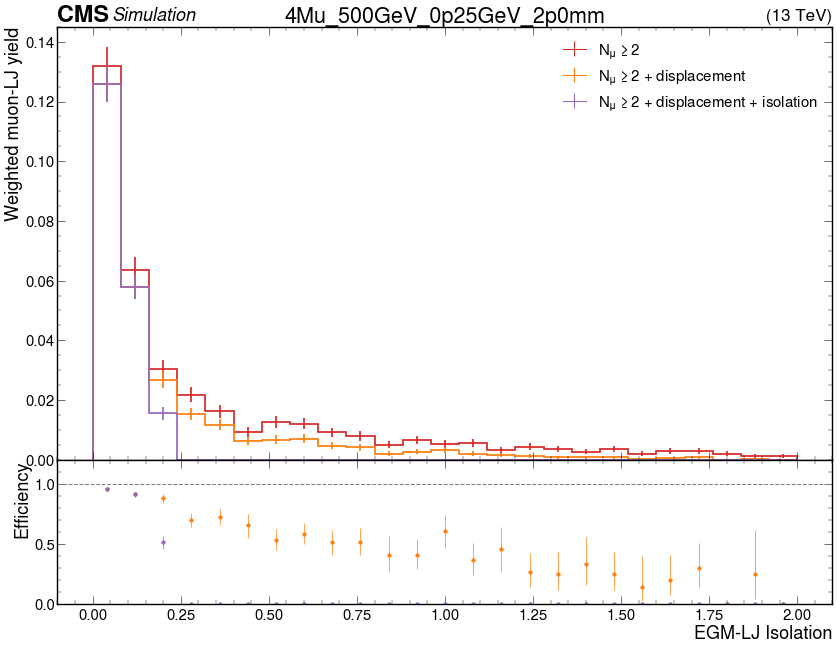

In [8]:
later_histograms = [
    "mu_lj_pt",
    "mu_lj_muon_min_dxy",
    "mu_lj_iso",
    "egm_lj_iso",
]
for sample in available_samples():
    for hist_name in later_histograms:
        fig = plot_overlay(
            sample,
            hist_name,
            LATER_CHANNELS,
            normalized=False,
            ratio_denominator=CHANNELS["nmu_ge2"],
        )
        show_and_close(fig, f"subsequent_{hist_name}_{sample}.pdf")

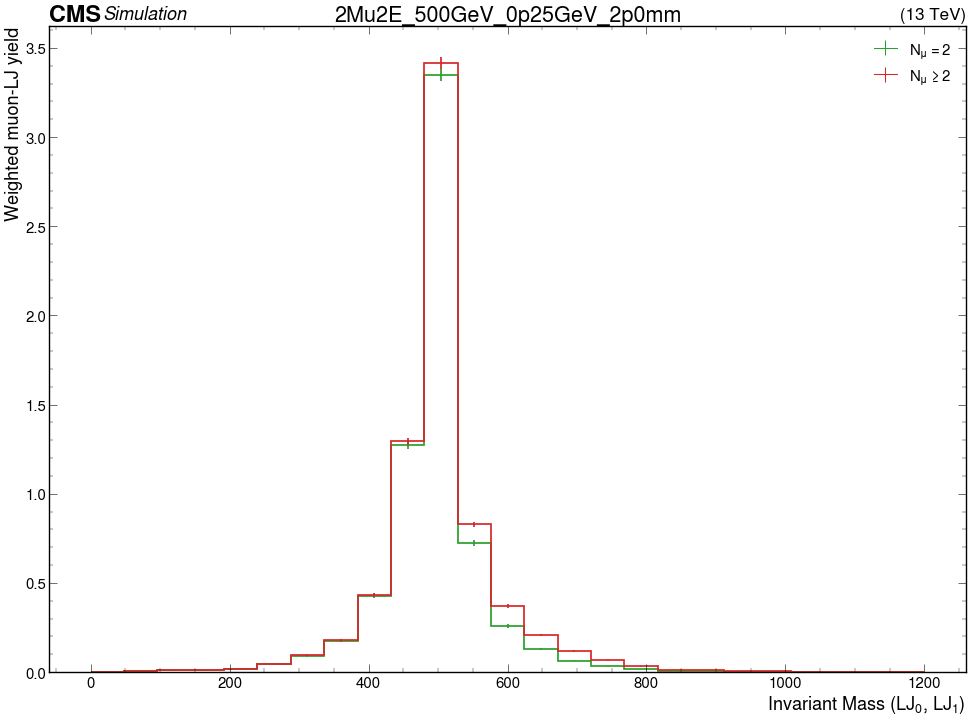

/tmp/ipykernel_947/3319563796.py:10: RuntimeWarning: Skip 4Mu_500GeV_0p25GeV_2p0mm/lj_lj_invmass: histogram is unavailable
  warnings.warn(


In [11]:
final_mass_channels = [
    CHANNELS["nmu_eq2"],
    CHANNELS["nmu_ge2"],
]

for sample in available_samples():
    hist_name = next(
        (
            histogram
            for topology, histogram in FINAL_VALIDATION_HISTOGRAMS.items()
            if topology in sample
        ),
        None,
    )

    if hist_name is None:
        warnings.warn(
            f"Skip final mass plot: unknown sample topology for {sample}",
            RuntimeWarning,
        )
        continue

    fig = plot_overlay(
        sample,
        hist_name,
        final_mass_channels,
        normalized=False,
        ratio_denominator=None,
    )
    show_and_close(
        fig,
        f"final_mass_shape_{hist_name}_{sample}.pdf",
    )

## 10. Automatic numerical summary

In [ ]:
summary_rows = []
for sample in available_samples():
    baseline = weighted_lj_yield(sample, CHANNELS["baseline"])
    exactly_two = weighted_lj_yield(sample, CHANNELS["nmu_eq2"])
    at_least_two = weighted_lj_yield(sample, CHANNELS["nmu_ge2"])
    even_charge = weighted_lj_yield(sample, CHANNELS["even_charge"])
    row = {
        "Sample": sample,
        "Baseline yield": baseline,
        "N_mu = 2 yield": exactly_two,
        "N_mu >= 2 yield": at_least_two,
        "N_mu >= 2 efficiency": safe_divide(at_least_two, baseline),
        "Gain relative to N_mu = 2": safe_divide(
            at_least_two - exactly_two, exactly_two,
        ),
        "Even-charge efficiency": safe_divide(even_charge, baseline),
    }
    summary_rows.append(row)
    print(f"\n{sample}")
    print(f"  baseline yield:              {baseline:.6g}")
    print(f"  N_mu = 2 yield:              {exactly_two:.6g}")
    print(f"  N_mu >= 2 yield:             {at_least_two:.6g}")
    print(
        "  N_mu >= 2 efficiency:        "
        f"{safe_divide(at_least_two, baseline):.3%}"
    )
    print(
        "  gain relative to N_mu = 2:   "
        f"{safe_divide(at_least_two - exactly_two, exactly_two):+.3%}"
    )
    print(
        "  even-charge efficiency:      "
        f"{safe_divide(even_charge, baseline):.3%}"
    )

summary_table = pd.DataFrame(summary_rows)
display(summary_table.style.format({
    "Baseline yield": "{:.6g}",
    "N_mu = 2 yield": "{:.6g}",
    "N_mu >= 2 yield": "{:.6g}",
    "N_mu >= 2 efficiency": "{:.3%}",
    "Gain relative to N_mu = 2": "{:+.3%}",
    "Even-charge efficiency": "{:.3%}",
}))

## 11. Conclusion

Using the currently available signal samples and processed channels, the
\(N_\mu\geq2\) requirement retains the expected dimuon topology while recovering events with
additional reconstructed muon candidates relative to an exactly-two requirement. The existing
muon-LJ transverse-momentum and matched-dark-photon response distributions show only modest
differences for these benchmark outputs, but their normalized overlays and ratio panels should
be checked for visible localized distortions. The final LJ-LJ mass distributions are shown
separately with their weighted normalization and without a ratio panel.

The reconstructed even-charge requirement is kept separate from the multiplicity definition.
Charge robustness as a function of PF/DSA reconstruction category and generated displacement
requires additional dedicated outputs and is not evaluated here. Displacement and isolation
remain subsequent LJ-level selections.

## Studies requiring additional processing

- PF-PF, PF-DSA, and DSA-DSA category-dependent reconstructed-charge efficiency;
- efficiency versus generated dark-photon \(L_{xy}\);
- a broader lifetime benchmark scan;
- any observable or channel not stored in the current coffea outputs.

These studies are intentionally not implemented in this notebook.